In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from openai import OpenAI
from litellm import completion
from IPython.display import display
from data_prep.parser import scrub, parse
from data_prep.items import Item
load_dotenv(override=True)


True

In [2]:
hf_token = os.environ['HF_TOKEN']

login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# Load dataset from Huggingface

In [3]:
data_set = load_dataset("Shopify/product-catalogue")



In [4]:
train_ds = data_set['train']
holdout_ds = data_set['test']

split_ds = holdout_ds.train_test_split(test_size=0.5, seed=42)
test_ds = split_ds['train']
validation_ds = split_ds['test']


print(f"Number of training examples: {len(train_ds)}")
print(f"Number of test examples: {len(test_ds)}")
print(f"Number of validation examples: {len(validation_ds)}")


Number of training examples: 38631
Number of test examples: 4829
Number of validation examples: 4829


Full data point example:
{'product_title': 'Airplane Piggy Bank', 'product_description': 'The sweetest gift!', 'product_image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=785x734 at 0x160FE6000>, 'potential_product_categories': ['Toys & Games > Toys > Flying Toys', 'Home & Garden > Decor > Piggy Banks & Money Jars', 'Toys & Games > Toys > Flying Toys > Model Aircrafts', 'Arts & Entertainment > Hobbies & Creative Arts > Arts & Crafts > Art & Crafting Materials > Pottery & Sculpting Materials > Clay & Modeling Dough > Clay > Sculpting Clay', 'Toys & Games > Toys > Beach & Sand Toys > Sand Castle Molds', 'Hardware > Tools > Dollies & Hand Trucks', 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks', 'Toys & Games > Toys > Play Vehicles > Toy Airplanes'], 'ground_truth_brand': 'Child to Cherish', 'ground_truth_is_secondhand': False, 'ground_truth_category': 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks'}
Ground truth category: Home & Garden > Hous

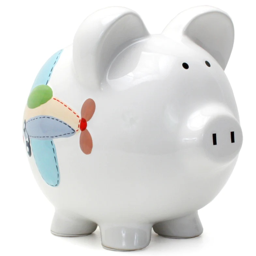

In [5]:
print("Full data point example:")
print(train_ds[0])
print("Ground truth category:", test_ds[0]["ground_truth_category"])
img = train_ds[0]["product_image"]
print(type(img))
display(img.resize((256, 256)))

## Collect the top level categories from training data

One can run the following block of code for the first time to automatically collect the cateogories from *trainning data set* . Alternatively, if the list of categories readily available, skip to the next block of code.

In [6]:
#extract top level category from the ground truth category
# def top_level_category_extractor(example):
#     top_lev = example['ground_truth_category'].split(' > ')[0]
#     return top_lev

# top_level_list = set([top_level_category_extractor(example) for example in train_ds])

In [7]:
top_level_list = {'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Gift Cards', 'Hardware', 'Home & Garden', 'Sporting Goods', 'Electronics', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Media', 'Toys & Games', 'Religious & Ceremonial', 'Luggage & Bags', 'Cameras & Optics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Vehicles & Parts', 'Health & Beauty', 'Business & Industrial', 'Services'}


# Exploring data set

#### Item with longest product description

In [13]:
longest_item_description = None
max_len = 0
for indx, item in enumerate(train_ds):
    desc_len = len(item['product_description'])
    if desc_len > max_len:
        max_len = desc_len
        longest_item_description = item
        lindx = indx

print("Length of longest product description:")
print(len(longest_item_description['product_description']))
print("id of the longest description item:", lindx)



Length of longest product description:
50937
id of the longest description item: 37826


Length of longest product description: 50937

id of the longest description item: 37826

In [ ]:
lengths = [len(item['product_description']) for item in train_ds]
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

#### Item with longest product title

In [12]:
longest_item_title = None
max_len = 0
for indx, item in enumerate(train_ds):
    desc_len = len(item['product_title'])
    if desc_len > max_len:
        max_len = desc_len
        longest_item_title = item
        lindx = indx

print("Length of longest product title:")
print(len(longest_item_title['product_title']))
print("id of the longest title item:", lindx)

Length of longest product title:
255
id of the longest title item: 2205


The item with the longest product title is item 2205th in the training data.
Length of longest product title: 255

In [ ]:
lengths = [len(item['product_title']) for item in train_ds]
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 255, 20))
plt.show()

# Cleaning data

In [8]:
#Data point will be scrubbed by removing barcode and converting to lowercase. This is done to remove any noise from the data and to make it easier for the model to learn from the data.
print("------------Original data point------------------:")
print(train_ds[10]['product_title'])
print(train_ds[10]['product_description'])
print("------------Scrubbed data point------------------:")
print(scrub(train_ds[10]['product_title'], train_ds[10]['product_description']))


------------Original data point------------------:
HP1044 SAUER TUROLLA PUMP
HP1044 Hydraulic pump is an original Danfoss© part produced in Germany. It has been engineered to superior standards, and is compatible with Sandvik© original specifications. HP1044 Sauer Turolla Pump is a reliable and efficient hydraulic pump designed for optimal performance in demanding industrial environments. With its precision engineering and durable construction, it delivers consistent hydraulic power to meet the needs of various applications with reliability and longevity. The unit weight is 12.5kg. HS code 8474909000. Continue exploring our store, for more PEAK quality parts!
------------Scrubbed data point------------------:
SAUER TUROLLA PUMP Hydraulic pump is an original Danfoss© part produced in Germany. It has been engineered to superior standards, and is compatible with Sandvik© original specifications. Sauer Turolla Pump is a reliable and efficient hydraulic pump designed for optimal performance

In [14]:
print(len(train_ds[37826]['product_title']))
cleaned_item = parse(train_ds[37826])
print(len(cleaned_item.title))
print(len(cleaned_item.category))
print(len(cleaned_item.full))


78
78
15
2579


# Push to HuggingFace

In [ ]:
username = "leearum95"
# full = f"{username}/items_raw_full"
# lite = f"{username}/items_raw_lite"

# train = sample[:800_000]
# val = sample[800_000:810_000]
# test = sample[810_000:]

# Item.push_to_hub(full, train, val, test)

# train_lite = train[:20_000]
# val_lite = val[:1_000]
# test_lite = test[:1_000]

# Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Run one example using ChatGPT 5.1, we see that the categorization diverges from the ground truth classification.